In [6]:
# modules/config.py
import re
import glob
import json
import numpy as np
import pandas as pd
from functools import lru_cache
from collections import defaultdict
from sklearn.metrics import confusion_matrix


# —— Task labels (rows: 7 GT classes; columns: 7 classes + Other)
CATEGORIES = [
    "Appendicitis", "Cholecystitis", "Diverticulitis", "Pancreatitis", 
    # "Pneumonia", "Pulm. embolism", "UTI"
]
PRED_CATEGORIES = CATEGORIES + ["Other"]

DATASET_TO_CATEGORY = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    # "pneumonia": "Pneumonia",
    # "pulmonary_embolism": "Pulm. embolism",
    # "uti": "UTI",
}

# —— Colorblind-friendly: Okabe-Ito palette plus gray for Other (consistent across Sankey diagrams and legends)
OKABE_ITO = [
    "#E69F00", "#56B4E9", "#009E73","#F0E442", 
    "#0072B2", "#D55E00", "#CC79A7"
]
OTHER_GREY = "#BABAD4"
COLOR_MAP = {cls: OKABE_ITO[i % len(OKABE_ITO)] for i, cls in enumerate(CATEGORIES)}
COLOR_MAP["Other"] = OTHER_GREY


In [10]:
import os
from openai import OpenAI
from dotenv import load_dotenv, find_dotenv

def _title_keep(s: str) -> str:
    # More robust case normalization: title-case only the first letter and preserve internal spaces
    return " ".join(w[:1].upper() + w[1:].lower() for w in s.split())

def allowed_categories_for_case(gt: str, include_other: bool = True) -> list[str]:
    """在 decision=False 的情况下，从候选中移除 GT；保留 Other。"""
    allowed = [c for c in CATEGORIES if c != gt]
    if include_other and "Other" not in allowed:
        allowed.append("Other")
    return allowed

# --- LLM client ---

load_dotenv(find_dotenv(), override=True)
client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url=os.getenv("OPENAI_BASE_URL")
)

def classify_with_llm(assistant_diag: str, allowed_tuple: tuple[str, ...]) -> str:
    # label_list = "\n".join(f"- {c}" for c in CATEGORIES)
    allowed = list(allowed_tuple)
    label_list = "\n".join(f"- {c}" for c in allowed)
    prompt = f"""
    You are a medical classification expert.

    Pick ONE category that best matches the diagnosis from the list below.
    If none fits, return "Other".

    Categories:
    {label_list}

    Rules:
    - If differential ("vs", "?", "rule out"), choose the most likely single category.
    - Return ONLY the category name.
    Assistant Diagnosis: "{assistant_diag}"
    """.strip()
    
    response = client.chat.completions.create(
        model="GPT-OSS-120B", #"gpt-4o-2024-08-06", #"gpt-5.1", #"litellm/openai/medgemma-27b-it-fp8-dynamic", #"medgemma-27b-it-q6", #"Qwen3-235B-A22B-FP8", #"Llama-4-Maverick-17B-128E-Instruct-FP8", #"gpt-4o",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_completion_tokens=128,
    )
    out = _title_keep((response.choices[0].message.content or "").strip())
    return out if out in allowed else ("Other" if "Other" in allowed else allowed[0])



In [3]:
# AIDOC
import pandas as pd
import numpy as np
import os, glob, json
from sklearn.metrics import confusion_matrix

def _is_true(val) -> bool:
    if isinstance(val, bool): return val
    if isinstance(val, (int, np.integer)): return int(val) == 1
    if isinstance(val, str): return val.strip().lower() in {"true","1","yes","y"}
    return False



def generate_aidoc_confusion_and_sankey(
    jsonl_dir: str,
    save_dir: str,
    min_count_sankey: int = 1,
):
    os.makedirs(save_dir, exist_ok=True)
    gt_labels, pred_labels = [], []
    error_records = []

    pattern = os.path.join(jsonl_dir, "**", "*_diagnosis_results.jsonl")
    files = glob.glob(pattern, recursive=True)
    print(f"📂 Found {len(files)} files")

    for fp in files:
        dataset_name = os.path.basename(os.path.dirname(fp))  # Parent directory name.
        gt = DATASET_TO_CATEGORY.get(dataset_name.lower())
        if not gt:
            print(f"  ⚠️ Skip unknown dataset {dataset_name}: {fp}")
            continue

        with open(fp, "r", encoding="utf-8") as f:
            for ln, line in enumerate(f, 1):
                line = line.strip()
                if not line: continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    print(f"  ⚠️ Bad JSON at {fp}:{ln}")
                    continue

                gt_labels.append(gt)

                if _is_true(rec.get("decision")):
                    pred = gt  # Rule: correct = GT.
                else:
                    diag = rec.get("assistant_diagnosis", "") or ""
                    allowed = allowed_categories_for_case(gt, include_other=True)
                    pred = classify_with_llm(diag, tuple(allowed))
                    error_records.append({
                        "hadm_id": rec.get("hadm_id"),
                        "ground_truth_class": gt,
                        "assistant_diagnosis": diag,
                        "assigned_class": pred,
                    })
                pred_labels.append(pred)

    # Misclassified samples
    with open(os.path.join(save_dir, "combined_errors.jsonl"), "w", encoding="utf-8") as ef:
        for r in error_records:
            ef.write(json.dumps(r, ensure_ascii=False) + "\n")

    # Confusion matrix (7x8).
    cm = confusion_matrix(gt_labels, pred_labels, labels=PRED_CATEGORIES)
    df_cm = pd.DataFrame(cm, index=PRED_CATEGORIES, columns=PRED_CATEGORIES)
    df_cm = df_cm.loc[CATEGORIES, PRED_CATEGORIES]     # Seven rows, including the Other column.
    df_cm.to_csv(os.path.join(save_dir, "combined_confusion_matrix.csv"))

    # Row normalization (percentages)
    df_row_norm = df_cm.div(df_cm.sum(axis=1).replace(0, np.nan), axis=0)
    df_row_norm.to_csv(os.path.join(save_dir, "combined_confusion_matrix_row_norm.csv"))

    # Sankey edge table: all flows and misclassified flows.
    edges = (
        pd.DataFrame({"gt": gt_labels, "pred": pred_labels})
        .value_counts(["gt", "pred"])
        .reset_index(name="count")
        .sort_values(["gt", "pred"])
    )
    edges[edges["count"] >= max(1, int(min_count_sankey))]\
        .to_csv(os.path.join(save_dir, "sankey_edges_all.csv"), index=False)

    mis = edges.query("gt != pred")
    mis[mis["count"] >= max(1, int(min_count_sankey))]\
        .to_csv(os.path.join(save_dir, "sankey_edges_mis.csv"), index=False)

    print("✅ Outputs written to:", save_dir)


In [11]:
# CDM
import os, re, glob, json
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix


def _is_gracious_correct(val) -> bool:
    """
    CDM 的正确性：gracious_diagnosis_score == 1 视为正确。
    兼容数字/字符串输入，严格等于 1（允许极小浮点误差）。
    """
    try:
        v = float(val)
        return abs(v - 1.0) < 1e-9
    except Exception:
        return str(val).strip() == "1"


def generate_cdm_confusion_and_sankey(
    jsonl_dir: str,   # Flat directory containing CDM results.
    save_dir: str,    # Output directory.
    min_count_sankey: int = 1
):
    os.makedirs(save_dir, exist_ok=True)

    gt_labels, pred_labels = [], []
    error_records = []

    # Current directory only; non-recursive
    pattern = os.path.join(jsonl_dir, "*_diagnosis_results_fuzzy.jsonl")
    files = glob.glob(pattern)
    print(f"📂 Found {len(files)} CDM diagnosis result files to process.")

    for fp in files:
        # Parse the dataset name from the filename
        m = re.search(r"(\w+)_diagnosis_results_fuzzy\.jsonl$", os.path.basename(fp))
        if not m:
            print(f"  ⚠️ Skip unmatched filename: {fp}")
            continue
        dataset_name = m.group(1)
        gt = DATASET_TO_CATEGORY.get(dataset_name.lower())
        if not gt:
            print(f"  ⚠️ Unknown dataset '{dataset_name}', skip: {fp}")
            continue

        print(f"  -> Processing {fp}")
        with open(fp, "r", encoding="utf-8") as f:
            for ln, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    print(f"    ⚠️ Bad JSON at {fp}:{ln}")
                    continue

                gt_labels.append(gt)

                if _is_gracious_correct(rec.get("gracious_diagnosis_score")):
                    # ★ Correct samples: prediction = GT (consistent with the original AIDOC strategy)
                    pred = gt
                else:
                    diag = rec.get("assistant_diagnosis", "") or ""
                    allowed = allowed_categories_for_case(gt, include_other=True)  # Exclude GT and retain Other.
                    pred = classify_with_llm(diag, tuple(allowed))
                    # Record only misclassified samples (CDM has no reasoning)
                    error_records.append({
                        "hadm_id": rec.get("hadm_id"),
                        "ground_truth_class": gt,
                        "assistant_diagnosis": diag,
                        "assigned_class": pred,
                    })

                pred_labels.append(pred)

    # ---- Misclassified samples ----
    with open(os.path.join(save_dir, "combined_errors.jsonl"), "w", encoding="utf-8") as ef:
        for r in error_records:
            ef.write(json.dumps(r, ensure_ascii=False) + "\n")

    # ---- Confusion matrix: 7x8 (rows = 7 GT classes; columns = 7 classes + Other)----
    cm = confusion_matrix(gt_labels, pred_labels, labels=PRED_CATEGORIES)
    df_cm = pd.DataFrame(cm, index=PRED_CATEGORIES, columns=PRED_CATEGORIES)
    df_cm = df_cm.loc[CATEGORIES, PRED_CATEGORIES]
    df_cm.to_csv(os.path.join(save_dir, "combined_confusion_matrix.csv"))

    # Row normalization (percentages)
    df_row_norm = df_cm.div(df_cm.sum(axis=1).replace(0, np.nan), axis=0)
    df_row_norm.to_csv(os.path.join(save_dir, "combined_confusion_matrix_row_norm.csv"))

    # ---- Sankey edge tables (all flows and misclassified flows only)----
    edges = (
        pd.DataFrame({"gt": gt_labels, "pred": pred_labels})
        .value_counts(["gt", "pred"])
        .reset_index(name="count")
        .sort_values(["gt", "pred"])
    )
    edges[edges["count"] >= max(1, int(min_count_sankey))]\
        .to_csv(os.path.join(save_dir, "sankey_edges_all.csv"), index=False)

    mis = edges.query("gt != pred")
    mis[mis["count"] >= max(1, int(min_count_sankey))]\
        .to_csv(os.path.join(save_dir, "sankey_edges_mis.csv"), index=False)

    print("✅ Done:",
          f"\n  - confusion matrices -> {save_dir}/combined_confusion_matrix*.csv",
          f"\n  - sankey edges       -> {save_dir}/sankey_edges_*.csv",
          f"\n  - misclassified logs -> {save_dir}/combined_errors.jsonl")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

def setup_style():
    sns.set_theme(style="white", context="paper", font_scale=1.0)
    plt.rcParams.update({
        'figure.dpi': 600,
        'savefig.dpi': 600,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.02,

        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'],
        'pdf.fonttype': 42,
        'ps.fonttype': 42,
        'svg.fonttype': 'none',

        'axes.labelsize': 7,
        'xtick.labelsize': 6,
        'ytick.labelsize': 6,
        'legend.fontsize': 6,

        'axes.linewidth': 0.5,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'xtick.major.width': 0.4,
        'ytick.major.width': 0.4,
        'xtick.major.size': 2.5,
        'ytick.major.size': 2.5,

        'patch.edgecolor': 'none',
        'patch.linewidth': 0.0,
        'axes.grid': False,
        'figure.autolayout': False,
        'axes.titlepad': 4,
        'axes.labelpad': 3,
    })

    try:
        arial_path = "/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"
        fm.fontManager.addfont(arial_path)
    except Exception:
        pass


In [ ]:
# modules/plot_confusion.py
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

def plot_confusion_heatmap(
    benchmark: str,
    csv_path: str,
    save_dir: str,
    normalized: bool = False,
    title: str = "Diagnosis Confusion Matrix",
):
    """
    csv_path: combined_confusion_matrix.csv 或 combined_confusion_matrix_row_norm.csv
    normalized=False 时显示计数；True 时显示百分比。
    """
    setup_style()
    os.makedirs(save_dir, exist_ok=True)

    df = pd.read_csv(csv_path, index_col=0)
    if normalized:
        # annot = df.map(lambda v: "" if pd.isna(v) or v == 0 else f"{v*100:.0f}%")
        annot = df.map(lambda v: "" if pd.isna(v) or round(v * 100) == 0 else f"{v*100:.0f}%")
        cmap = "Blues"
    else:
        annot = df.map(lambda v: "" if pd.isna(v) or v == 0 else f"{int(v)}")
        cmap = "Blues"

    rows, _ = df.shape
    if benchmark == 'AIDOC':
        fig, ax = plt.subplots(figsize=(4.4, 3.0))
    else:
        fig, ax = plt.subplots(figsize=(2.8, 2.0))

    hm = sns.heatmap(
        df if not normalized else df,  # Plot directly when the CSV already contains proportions.
        annot=annot, fmt="", cmap=cmap,
        vmin=(0 if normalized else None),
        linewidths=0.5, linecolor="white",
        cbar=True, square=False,
        annot_kws={'fontsize': 5}
    )

    # ax.set_title(title, loc='left', weight='bold', fontsize=12)
    ax.set_xlabel("Agent Diagnosed Disease", fontsize=7)
    ax.set_ylabel("Ground Truth Disease", fontsize=7)
    ax.tick_params(axis='both', which='major', width=0.4, length=2.5,
                   direction='out', top=False, right=False, bottom=True, left=True)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    # ax.spines['left'].set_visible(True);  ax.spines['left'].set_linewidth(0.5)
    # ax.spines['bottom'].set_visible(True);ax.spines['bottom'].set_linewidth(0.5)

    cbar = hm.collections[0].colorbar
    cbar.outline.set_visible(False) 
    cbar.ax.tick_params(labelsize=6, width=0.4, length=2.5, direction='out')
    # cbar.outline.set_linewidth(0.5)
    if normalized:
        pass  # Optional: cbar.locator = MultipleLocator(0.1); cbar.update_ticks().

    base = os.path.splitext(os.path.basename(csv_path))[0]
    out = os.path.join(save_dir, f"{base}_heatmap")
    plt.tight_layout()
    plt.savefig(out + ".pdf", bbox_inches="tight")
    plt.savefig(out + ".svg", bbox_inches="tight")
    plt.savefig(out + ".png", bbox_inches="tight", dpi=600)
    # plt.close()
    print(f"✅ Heatmap saved to: {save_dir}")


In [4]:
# modules/plot_sankey.py
import os
import pandas as pd
import plotly.graph_objects as go

def _hex_to_rgba(hex_color: str, alpha: float) -> str:
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha:.2f})"


def plot_sankey_from_edges(
    edges_csv: str, save_dir: str,
    title: str = "Ground Truth → Agent Diagnosis (Misdiagnoses only)",
    color_by: str = "gt",     # 'gt' or 'pred'.
    html_name: str = "sankey_gt_to_pred.html",
    height: int | None = None
):
    """
    edges_csv: sankey_edges_mis.csv 或 sankey_edges_all.csv，需包含列 ['gt','pred','count']
    color_by: 按来源或去向着色；'gt' 推荐用于看“谁错向哪里”
    """
    os.makedirs(save_dir, exist_ok=True)
    df = pd.read_csv(edges_csv)
    if df.empty:
        print("⚠️ Empty edges csv.")
        return

    gt_labels = df['gt'].unique().tolist()
    pred_labels = df['pred'].unique().tolist()

    left_nodes  = [f"GT · {c}"   for c in gt_labels]
    right_nodes = [f"Pred · {c}" for c in pred_labels]
    labels = left_nodes + right_nodes
    idx = {lab: i for i, lab in enumerate(labels)}

    source = [idx[f"GT · {g}"]   for g in df['gt']]
    target = [idx[f"Pred · {p}"] for p in df['pred']]
    value  = df['count'].astype(float).tolist()
    link_label = [f"{g} → {p}<br>n={c}" for g, p, c in zip(df['gt'], df['pred'], df['count'])]

    def pick_color(name: str) -> str:
        return _hex_to_rgba(COLOR_MAP.get(name, "#888888"), 0.55)

    link_color = [pick_color(n) for n in (df['gt'] if color_by=="gt" else df['pred'])]
    node_colors = (
        [_hex_to_rgba(COLOR_MAP.get(g, "#888888"), 0.90) for g in gt_labels] +
        [_hex_to_rgba(COLOR_MAP.get(p, "#888888"), 0.90) for p in pred_labels]
    )

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=10, thickness=10,
            line=dict(color="rgba(0,0,0,0)", width=0),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=source, target=target, value=value,
            label=link_label, color=link_color
        )
    )])

    if height is None:
        height = max(420, 28 * max(len(gt_labels), len(pred_labels)))

    fig.update_layout(
        # title=title, 
        font=dict(size=12, family="Arial"),
        margin=dict(l=10, r=10, t=40, b=10),
        height=height
    )

    out_html = os.path.join(save_dir, html_name)
    fig.write_html(out_html)
    print(f"✅ Sankey HTML saved to: {out_html}")

    # For a static figure, first:
    #   pip install -U kaleido plotly
    #   python -c "import kaleido; kaleido.get_chrome_sync()"
    # Then uncomment:
    fig.write_image(os.path.join(save_dir, "sankey_gt_to_pred.png"), scale=3)
    fig.write_image(os.path.join(save_dir, "sankey_gt_to_pred.svg"))


✅ Heatmap saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/diagnosis_matrix/run_5
✅ Heatmap saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/diagnosis_matrix/run_5
✅ Sankey HTML saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/diagnosis_matrix/run_5/sankey_gt_to_pred_mis.html


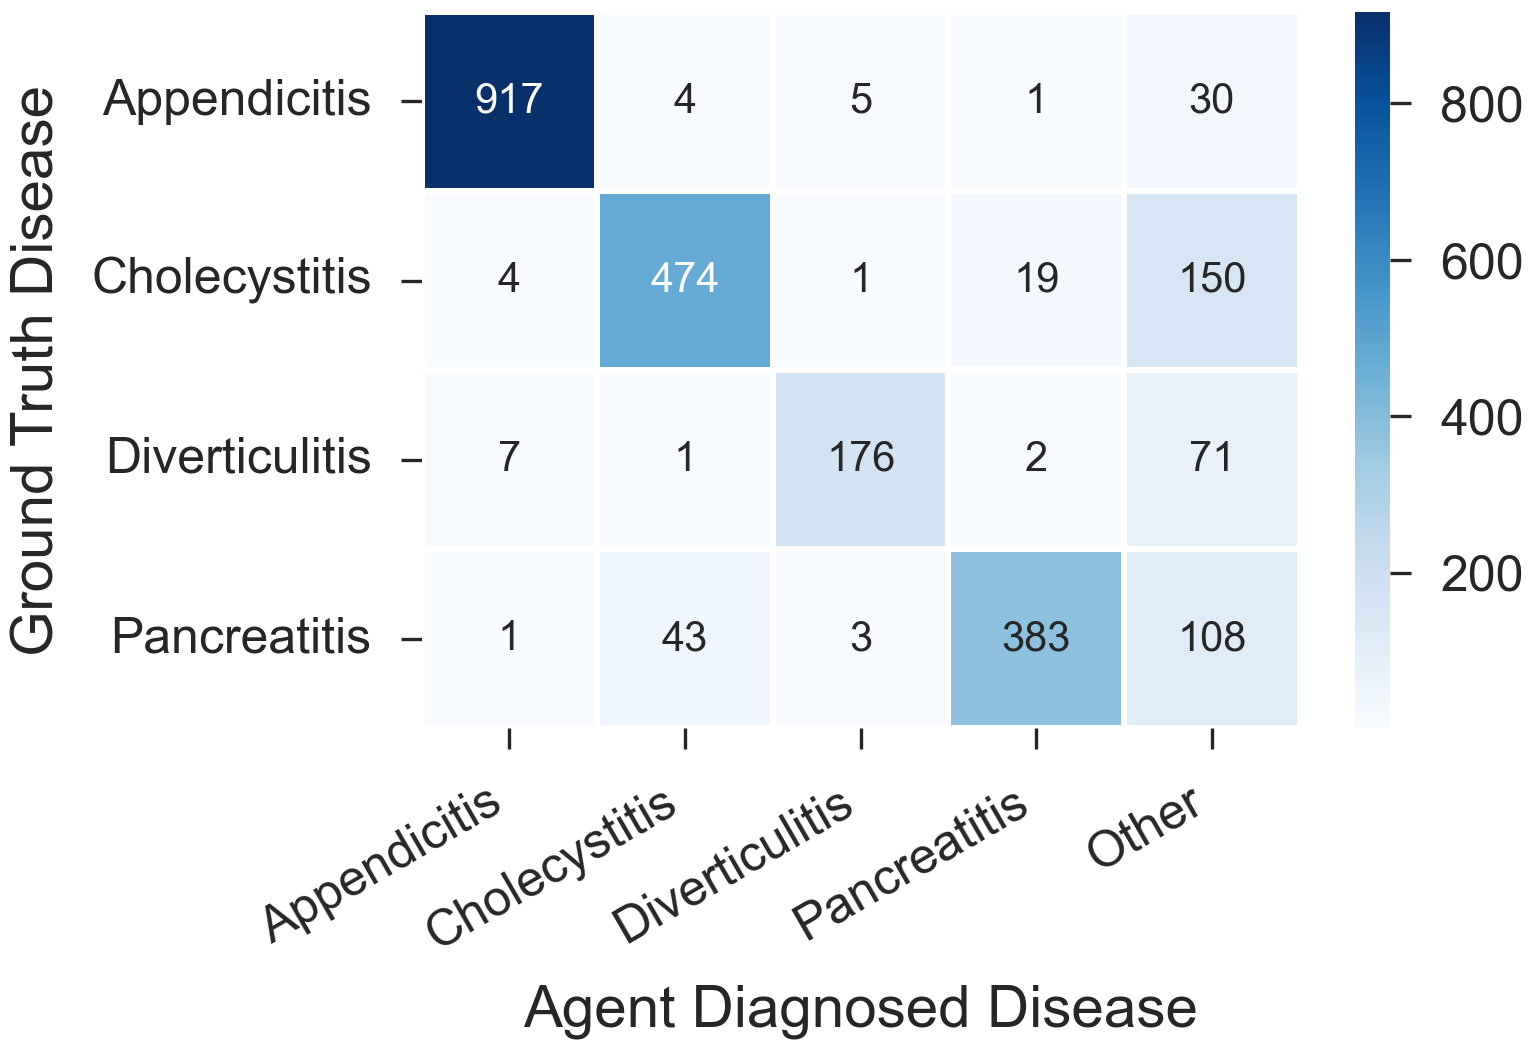

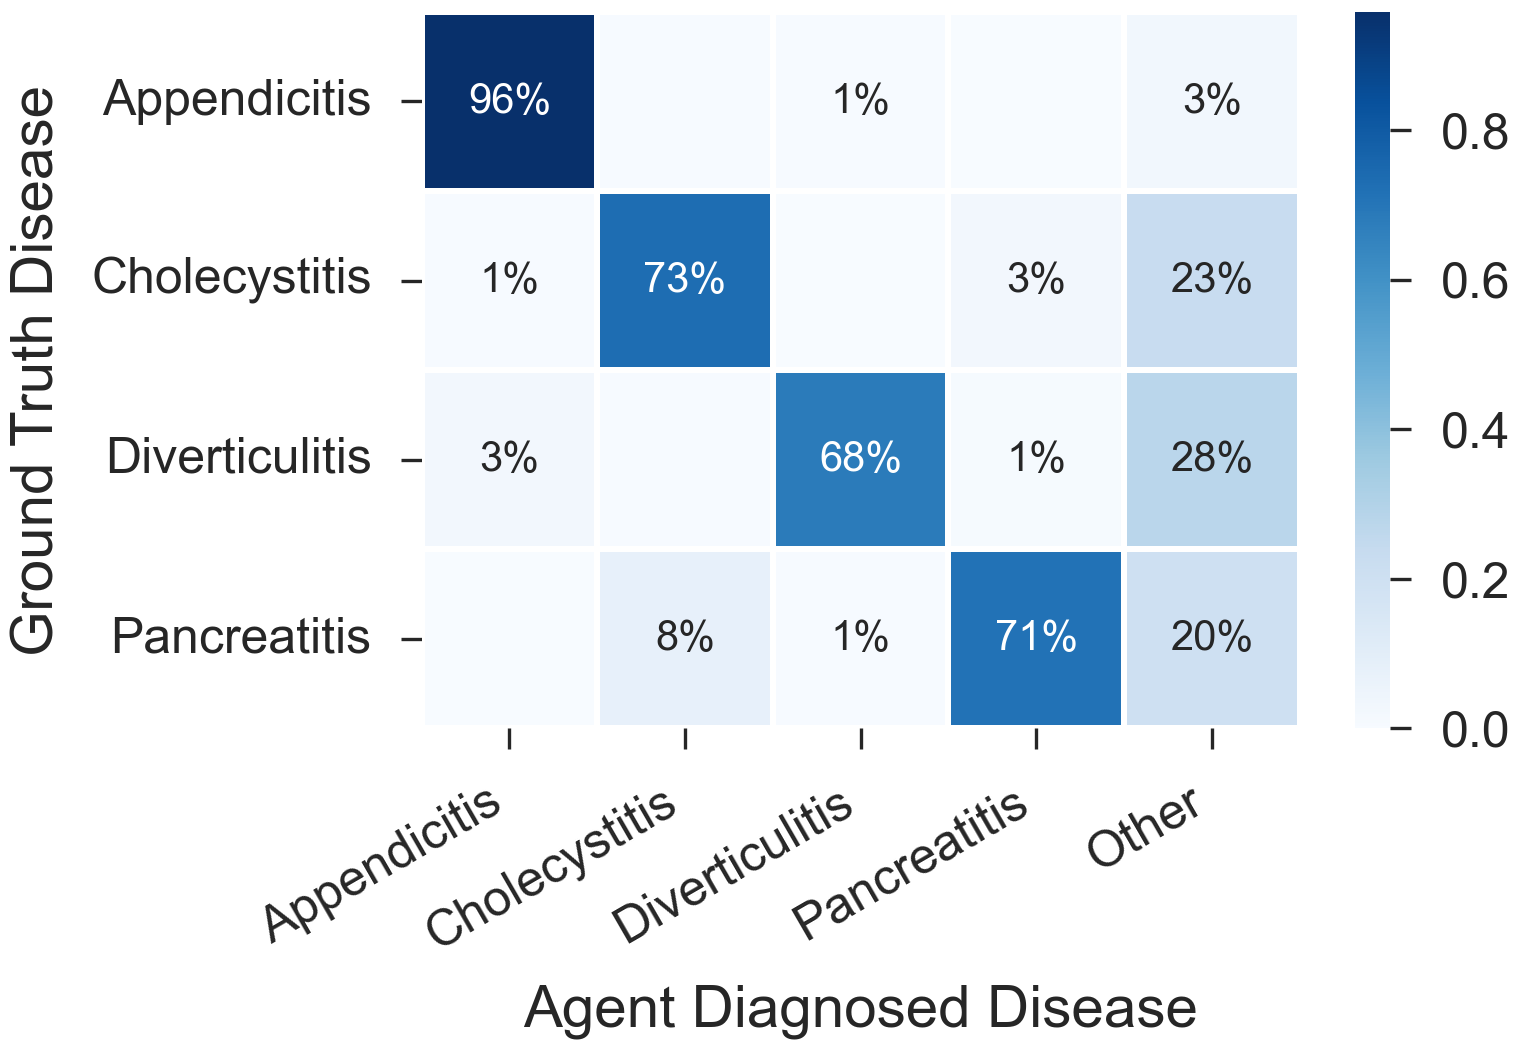

In [ ]:
# run_pipeline.py
import os

if __name__ == "__main__":
    # —— Input/output paths (adjust as needed)——
    benchmark = 'CDM'
    JSONL_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean/run_5"
    SAVE_DIR  = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/55_clean/diagnosis_matrix/run_5"

    # benchmark = 'AIDOC'
    # JSONL_DIR = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/5runs/63.10/run_4"
    # SAVE_DIR  = "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/diagnosis_matrix/run_4"

    # 1) Generate the confusion matrix, Sankey edge tables, and misclassified samples
    # if benchmark == 'AIDOC':
    #     generate_aidoc_confusion_and_sankey(
    #         jsonl_dir=JSONL_DIR,
    #         save_dir=SAVE_DIR,
    #         min_count_sankey=1,
    #     )
    # else:
    #     generate_cdm_confusion_and_sankey(
    #         jsonl_dir=JSONL_DIR,
    #         save_dir=SAVE_DIR,
    #         min_count_sankey=1
    #     )

    # 2) Plot confusion matrices (counts and row-normalized percentages)
    plot_confusion_heatmap(
        benchmark = benchmark,
        csv_path=os.path.join(SAVE_DIR, "combined_confusion_matrix.csv"),
        save_dir=SAVE_DIR,
        normalized=False,
        # title="Diagnosis Confusion Matrix - AIDOC (Counts)",
    )
    plot_confusion_heatmap(
        benchmark = benchmark,
        csv_path=os.path.join(SAVE_DIR, "combined_confusion_matrix_row_norm.csv"),
        save_dir=SAVE_DIR,
        normalized=True,
        # title="Diagnosis Confusion Matrix - AIDOC (Row-normalized %)",
    )

    # 3) Plot the Sankey diagram (misclassified flows); use edges_all to show all flows
    plot_sankey_from_edges(
        edges_csv=os.path.join(SAVE_DIR, "sankey_edges_mis.csv"),
        save_dir=SAVE_DIR,
        # title="Ground Truth → Agent Diagnosis (Misdisgnoses Only)",
        color_by="gt",                  # 'gt' shows where each class was misclassified; 'pred' shows which class each prediction became.
        html_name="sankey_gt_to_pred_mis.html",
    )
